# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# np.random.seed(42)

# Create Simple Dataset (200 students)
n = 200

X = pd.DataFrame({
    "Study_Hours": np.random.normal(15, 5, n),
    "Attendance": np.random.normal(75, 10, n),
    "Previous_Score": np.random.normal(70, 8, n),
    "Sleep_Hours": np.random.normal(7, 1, n)
})

y = (
    0.4 * X["Study_Hours"] +
    0.3 * X["Attendance"] +
    0.5 * X["Previous_Score"] +
    0.2 * X["Sleep_Hours"] +
    np.random.normal(0, 5, n)
)

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = Ridge(alpha=1.0)

# 5-Fold Cross Validation (R²)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="r2")

print("R² scores (5-Fold):", r2_scores)
print("Mean R²:", r2_scores.mean())

# Train vs Validation Check
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("\nTrain R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

print("\nTrain MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))


# Create pass/fail (pass if grade >= 50)
y_class = (y >= 50).astype(int)

clf = LogisticRegression()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = cross_val_score(clf, X_scaled, y_class, cv=skf, scoring="accuracy")

print("\nStratified K-Fold Accuracy:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())

R² scores (5-Fold): [0.44489637 0.40127509 0.30810721 0.4106903  0.59257079]
Mean R²: 0.4315079515242024

Train R²: 0.5037682646223764
Test R²: 0.4448963701995954

Train MSE: 22.76239366433007
Test MSE: 36.68285685422103

Stratified K-Fold Accuracy: [1.    1.    0.975 0.975 0.975]
Mean Accuracy: 0.985


C:\Users\ANKIT RAJ\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

n = 1000

X = pd.DataFrame({
    "Age": np.random.normal(50, 12, n),
    "Physiotherapy_Hours": np.random.normal(5, 2, n),
    "Health_Severity": np.random.normal(3, 1, n),
    "Hospital_Stay": np.random.normal(7, 3, n),
    "Sleep_Hours": np.random.normal(7, 1, n)
})

# Target Recovery Time (in days)
y = (
    0.3 * X["Age"] -
    2.0 * X["Physiotherapy_Hours"] +
    4.0 * X["Health_Severity"] +
    1.5 * X["Hospital_Stay"] -
    1.0 * X["Sleep_Hours"] +
    np.random.normal(0, 5, n)
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="r2")

print("R² Scores (5-Fold):", r2_scores)
print("Mean R²:", r2_scores.mean())

R² Scores (5-Fold): [0.76483199 0.75358979 0.72051123 0.72679473 0.6823424 ]
Mean R²: 0.7296140278473888


Scenario: Predicting Student Exam Performance
A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
- Number of study hours per week
- Attendance percentage in lectures
- Prior GPA (Grade Point Average)
- Participation in group projects (numeric engagement score)
- Average sleep hours during exam preparation
They collect data from 800 students across different departments and decide to use Linear Regression.
To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

np.random.seed(42)

# Create Dataset (800 students)
n = 800

X = pd.DataFrame({
    "Study_Hours": np.random.normal(15, 5, n),
    "Attendance": np.random.normal(80, 10, n),
    "GPA": np.random.normal(3.0, 0.5, n),
    "Project_Participation": np.random.normal(7, 2, n),
    "Sleep_Hours": np.random.normal(7, 1, n)
})

# Target variable
y = (
    2.5 * X["Study_Hours"] +
    0.4 * X["Attendance"] +
    10 * X["GPA"] +
    1.5 * X["Project_Participation"] +
    2.0 * X["Sleep_Hours"] +
    np.random.normal(0, 10, n)
)

# Prepare K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

# Manual Cross Validation Loop
for train_index, test_index in kf.split(X):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Scale inside each fold 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate R²
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

print("R² Scores (5-Fold):", r2_scores)
print("Mean R²:", np.mean(r2_scores))

R² Scores (5-Fold): [0.594467658765108, 0.6920582791307148, 0.6968675518709819, 0.5585185570261866, 0.7057249015221517]
Mean R²: 0.6495273896630287


Scenario: Predicting Student Exam Performance
A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
- Number of study hours per week
- Attendance percentage in lectures
- Prior GPA (Grade Point Average)
- Participation in group projects (numeric engagement score)
- Average sleep hours during exam preparation
They collect data from 800 students across different departments and decide to use Linear Regression.
To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

Linear (Degree 1) Mean R²: -0.8249097796313725
Balanced (Degree 3) Mean R²: -1.0890200405569863
Overfit (Degree 10) Mean R²: -2.7158812931966674


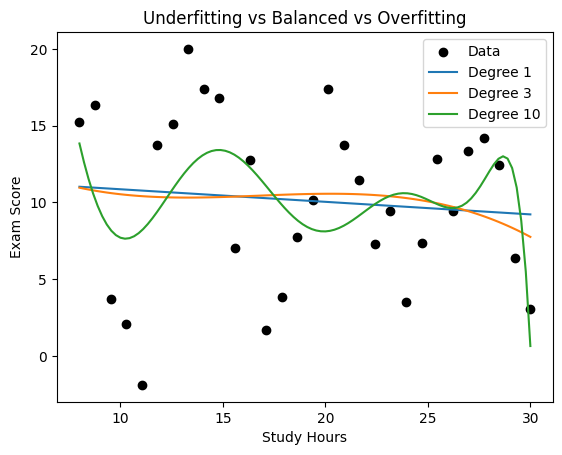

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score

np.random.seed(8)

# Create Dataset (30 students)
X = np.linspace(8, 30, 30).reshape(-1, 1)
y = 10 + 5*np.sin(X).ravel() + np.random.normal(scale=3, size=30)

# Define Three Models
linear_model = make_pipeline(
    PolynomialFeatures(degree=1),
    LinearRegression()
)

balanced_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

overfit_model = make_pipeline(
    PolynomialFeatures(degree=10),
    LinearRegression()
)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

linear_scores = cross_val_score(linear_model, X, y, cv=kf, scoring="r2")
balanced_scores = cross_val_score(balanced_model, X, y, cv=kf, scoring="r2")
overfit_scores = cross_val_score(overfit_model, X, y, cv=kf, scoring="r2")

print("Linear (Degree 1) Mean R²:", linear_scores.mean())
print("Balanced (Degree 3) Mean R²:", balanced_scores.mean())
print("Overfit (Degree 10) Mean R²:", overfit_scores.mean())

# Visualization
plt.scatter(X, y, color="black", label="Data")

X_plot = np.linspace(8, 30, 100).reshape(-1, 1)

linear_model.fit(X, y)
balanced_model.fit(X, y)
overfit_model.fit(X, y)

plt.plot(X_plot, linear_model.predict(X_plot), label="Degree 1")
plt.plot(X_plot, balanced_model.predict(X_plot), label="Degree 3")
plt.plot(X_plot, overfit_model.predict(X_plot), label="Degree 10")

plt.legend()
plt.title("Underfitting vs Balanced vs Overfitting")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

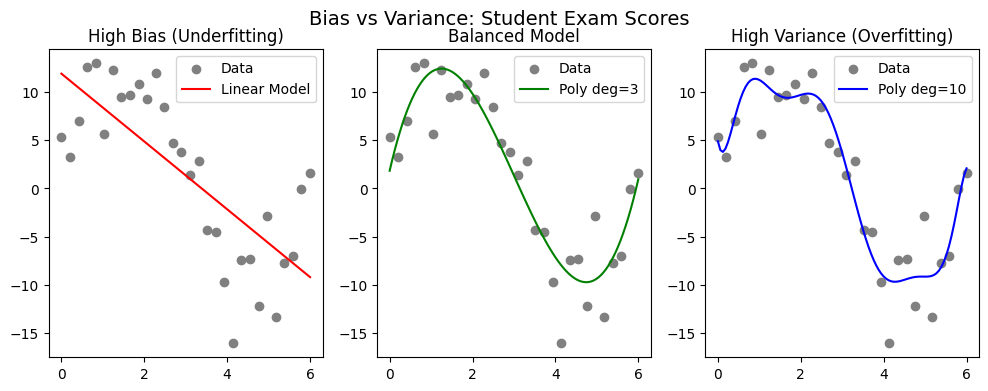

In [8]:
#2 nd code
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different 
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?

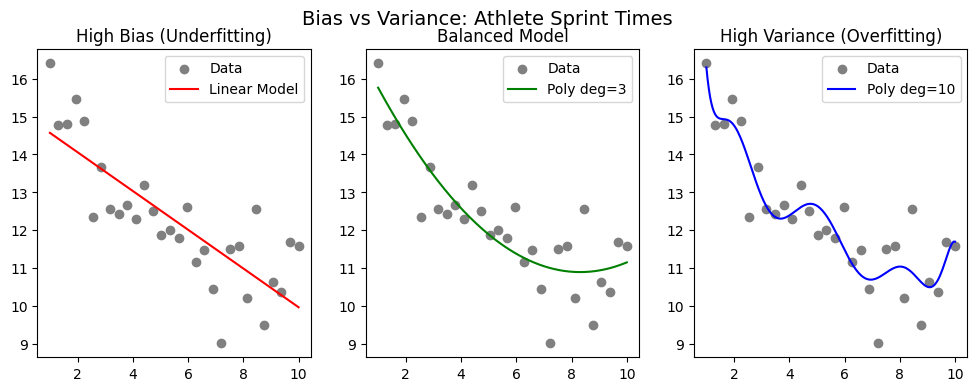

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


np.random.seed(0)
X = np.linspace(1, 10, 30).reshape(-1, 1)   
y = (15 - 2*np.log(X)).ravel() + np.random.normal(scale=0.8, size=30)


linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"
poly_model = make_pipeline(PolynomialFeatures(10), LinearRegression())    # complex curve


linear_model.fit(X, y)
balanced_model.fit(X, y)
poly_model.fit(X, y)


X_test = np.linspace(1, 10, 200).reshape(-1, 1)
y_linear = linear_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)
y_poly = poly_model.predict(X_test)

plt.figure(figsize=(12, 4))


plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Athlete Sprint Times", fontsize=14)
plt.show()